# 22.1 - Understanding Alternative Texture Features

This notebook explains the three texture feature families used in NB 22:
- **LBP (Local Binary Patterns)**: encodes local micro-texture by comparing each pixel to its neighbours
- **Gabor filters**: detects texture at specific frequencies and orientations (like a tunable frequency detector)
- **Laws' texture energy**: measures texture energy using predefined 1D kernels combined into 2D

Each section uses toy images and step-by-step computation before applying to a real ultrasound image.
The goal is to build intuition for what these methods measure and why they might (or might not)
capture tissue changes due to rejection.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import cv2
from skimage.feature import local_binary_pattern
from scipy.signal import convolve2d
import os
import pydicom

np.set_printoptions(precision=3, suppress=True)
print("Imports OK")

Imports OK


## Toy images with known textures

We start with 4 synthetic 64x64 images where we know the ground truth texture:
1. **Flat**: uniform intensity (no texture at all)
2. **Stripes**: regular horizontal bands (strong periodic texture)
3. **Gradient**: smooth diagonal change (no local texture, just global trend)
4. **Noise**: random values (maximally complex texture)

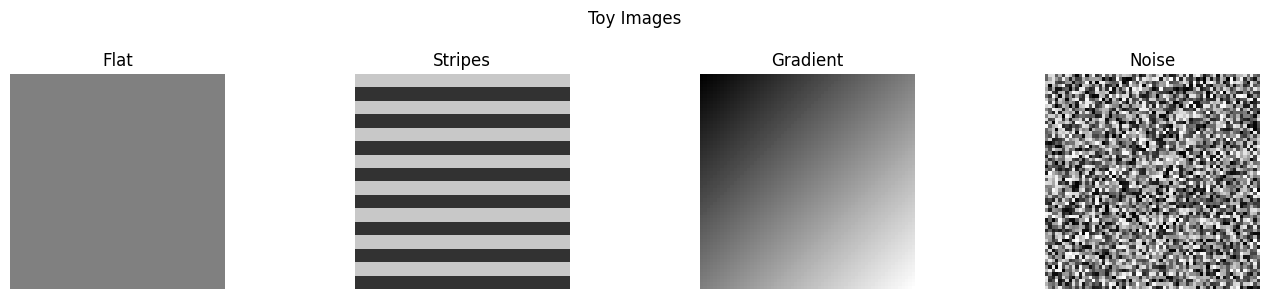

In [2]:
np.random.seed(42)
size = 64

# 1. Flat (uniform)
img_flat = np.full((size, size), 128, dtype=np.uint8)

# 2. Horizontal stripes (period = 8 pixels)
img_stripes = np.zeros((size, size), dtype=np.uint8)
for row in range(size):
    if (row // 4) % 2 == 0:
        img_stripes[row, :] = 200
    else:
        img_stripes[row, :] = 50

# 3. Diagonal gradient
x = np.linspace(0, 255, size)
y = np.linspace(0, 255, size)
xx, yy = np.meshgrid(x, y)
img_gradient = ((xx + yy) / 2).astype(np.uint8)

# 4. Random noise
img_noise = np.random.randint(0, 256, (size, size), dtype=np.uint8)

images = {
    "Flat": img_flat,
    "Stripes": img_stripes,
    "Gradient": img_gradient,
    "Noise": img_noise,
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img, cmap="gray", vmin=0, vmax=255)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("Toy Images", fontsize=12)
plt.tight_layout()
plt.show()

## LBP (Local Binary Patterns)

### How it works

For each pixel, LBP looks at P equally-spaced neighbours on a circle of radius R:
1. Compare each neighbour to the centre pixel
2. If neighbour >= centre: write 1, else write 0
3. Read the binary string clockwise → get a decimal number (the LBP code)

The **uniform** variant only distinguishes patterns with at most 2 binary transitions
(0→1 or 1→0). All other patterns are lumped into a single "non-uniform" bin.
This gives P+2 histogram bins (P uniform patterns + 1 non-uniform + 1 for all-zeros/all-ones).

**Intuition:** LBP encodes the local micro-structure. A pixel surrounded by brighter
neighbours gets a different code than one surrounded by darker neighbours. The
histogram of codes over the ROI summarizes the texture.

In [3]:
# Hand computation: one 3x3 patch
patch = np.array([
    [90, 120, 110],
    [95, 100, 130],  # centre = 100
    [80,  70, 105],
], dtype=np.uint8)

centre = patch[1, 1]
print(f"Centre pixel value: {centre}")
print(f"Patch:\n{patch}")
print()

# 8 neighbours in clockwise order starting from top-left
# Standard order: top-left, top, top-right, right, bottom-right, bottom, bottom-left, left
neighbours = [
    ("top-left", patch[0, 0]),
    ("top", patch[0, 1]),
    ("top-right", patch[0, 2]),
    ("right", patch[1, 2]),
    ("bottom-right", patch[2, 2]),
    ("bottom", patch[2, 1]),
    ("bottom-left", patch[2, 0]),
    ("left", patch[1, 0]),
]

print("Comparison (neighbour >= centre → 1, else 0):")
binary_string = ""
for pos, val in neighbours:
    bit = 1 if val >= centre else 0
    binary_string += str(bit)
    print(f"  {pos:12s}: {val:3d} >= {centre}? → {bit}")

print(f"\nBinary string: {binary_string}")
decimal_value = int(binary_string, 2)
print(f"Decimal (LBP code): {decimal_value}")
print(f"\nThis pattern has {sum(a != b for a, b in zip(binary_string, binary_string[1:] + binary_string[0]))} transitions")
print("(<=2 transitions = uniform pattern)")

Centre pixel value: 100
Patch:
[[ 90 120 110]
 [ 95 100 130]
 [ 80  70 105]]

Comparison (neighbour >= centre → 1, else 0):
  top-left    :  90 >= 100? → 0
  top         : 120 >= 100? → 1
  top-right   : 110 >= 100? → 1
  right       : 130 >= 100? → 1
  bottom-right: 105 >= 100? → 1
  bottom      :  70 >= 100? → 0
  bottom-left :  80 >= 100? → 0
  left        :  95 >= 100? → 0

Binary string: 01111000
Decimal (LBP code): 120

This pattern has 2 transitions
(<=2 transitions = uniform pattern)


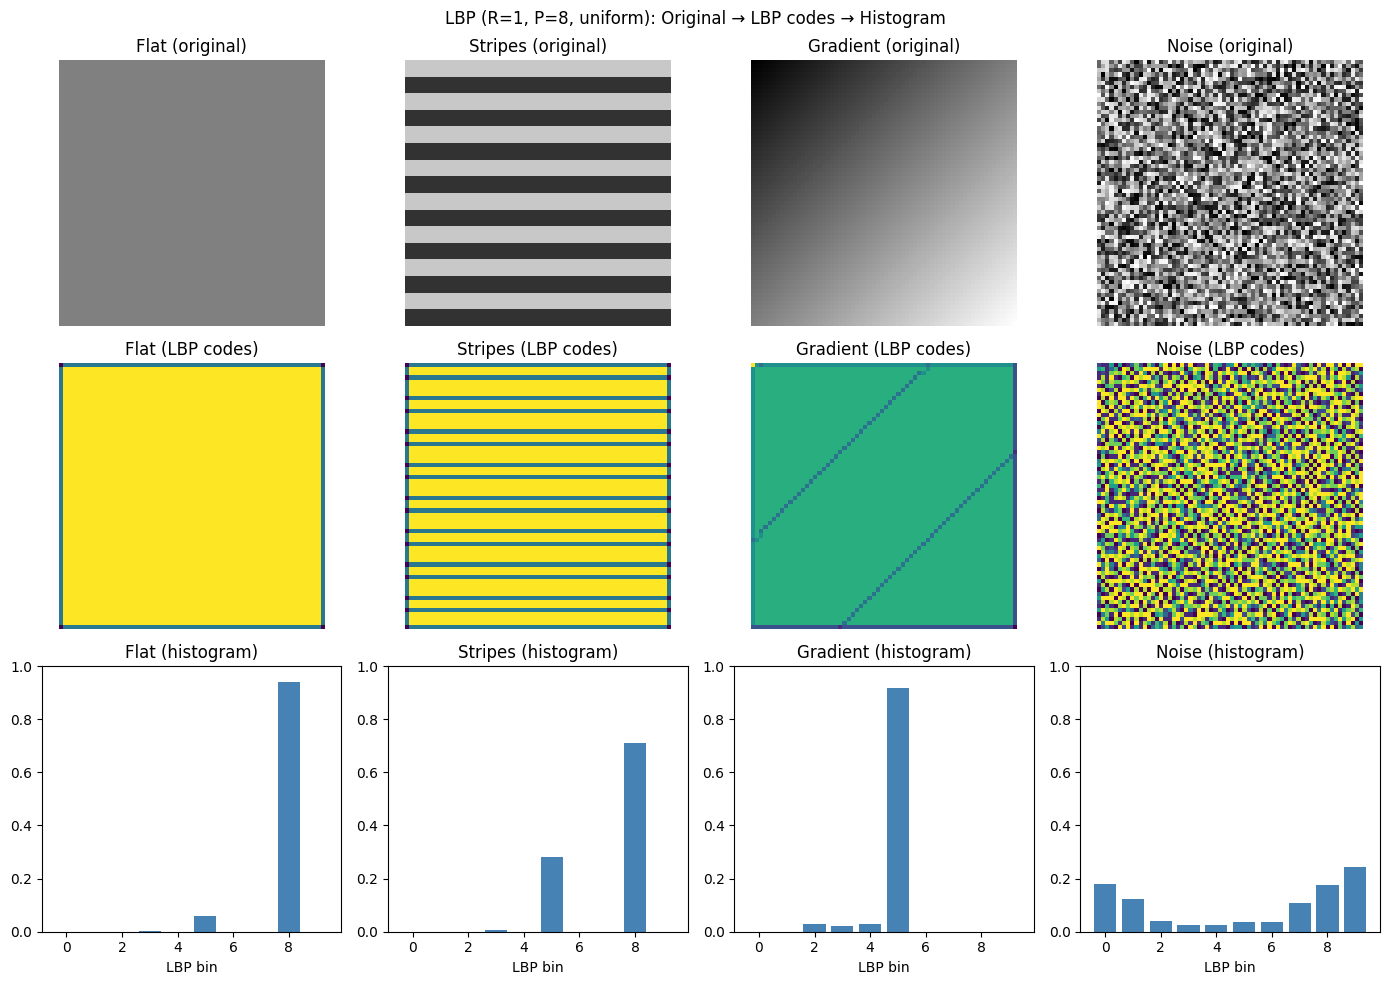

Key observations:
- Flat: all neighbours equal centre → single dominant bin (all-same pattern)
- Stripes: strong edge patterns → peaks at edge-related bins
- Gradient: smooth transitions → spread across uniform patterns
- Noise: random → spread across all bins including non-uniform (last bin)


In [4]:
# Apply LBP to all toy images (R=1, P=8)
radius = 1
n_points = 8
n_bins = n_points + 2  # 10 bins for uniform LBP

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for col, (name, img) in enumerate(images.items()):
    lbp_img = local_binary_pattern(img, n_points, radius, method="uniform")

    # Row 1: original
    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"{name} (original)")
    axes[0, col].axis("off")

    # Row 2: LBP image
    axes[1, col].imshow(lbp_img, cmap="viridis")
    axes[1, col].set_title(f"{name} (LBP codes)")
    axes[1, col].axis("off")

    # Row 3: histogram
    hist, _ = np.histogram(lbp_img, bins=n_bins, range=(0, n_bins), density=True)
    axes[2, col].bar(range(n_bins), hist, color="steelblue")
    axes[2, col].set_title(f"{name} (histogram)")
    axes[2, col].set_xlabel("LBP bin")
    axes[2, col].set_ylim(0, 1.0)

plt.suptitle("LBP (R=1, P=8, uniform): Original → LBP codes → Histogram", fontsize=12)
plt.tight_layout()
plt.show()

print("Key observations:")
print("- Flat: all neighbours equal centre → single dominant bin (all-same pattern)")
print("- Stripes: strong edge patterns → peaks at edge-related bins")
print("- Gradient: smooth transitions → spread across uniform patterns")
print("- Noise: random → spread across all bins including non-uniform (last bin)")

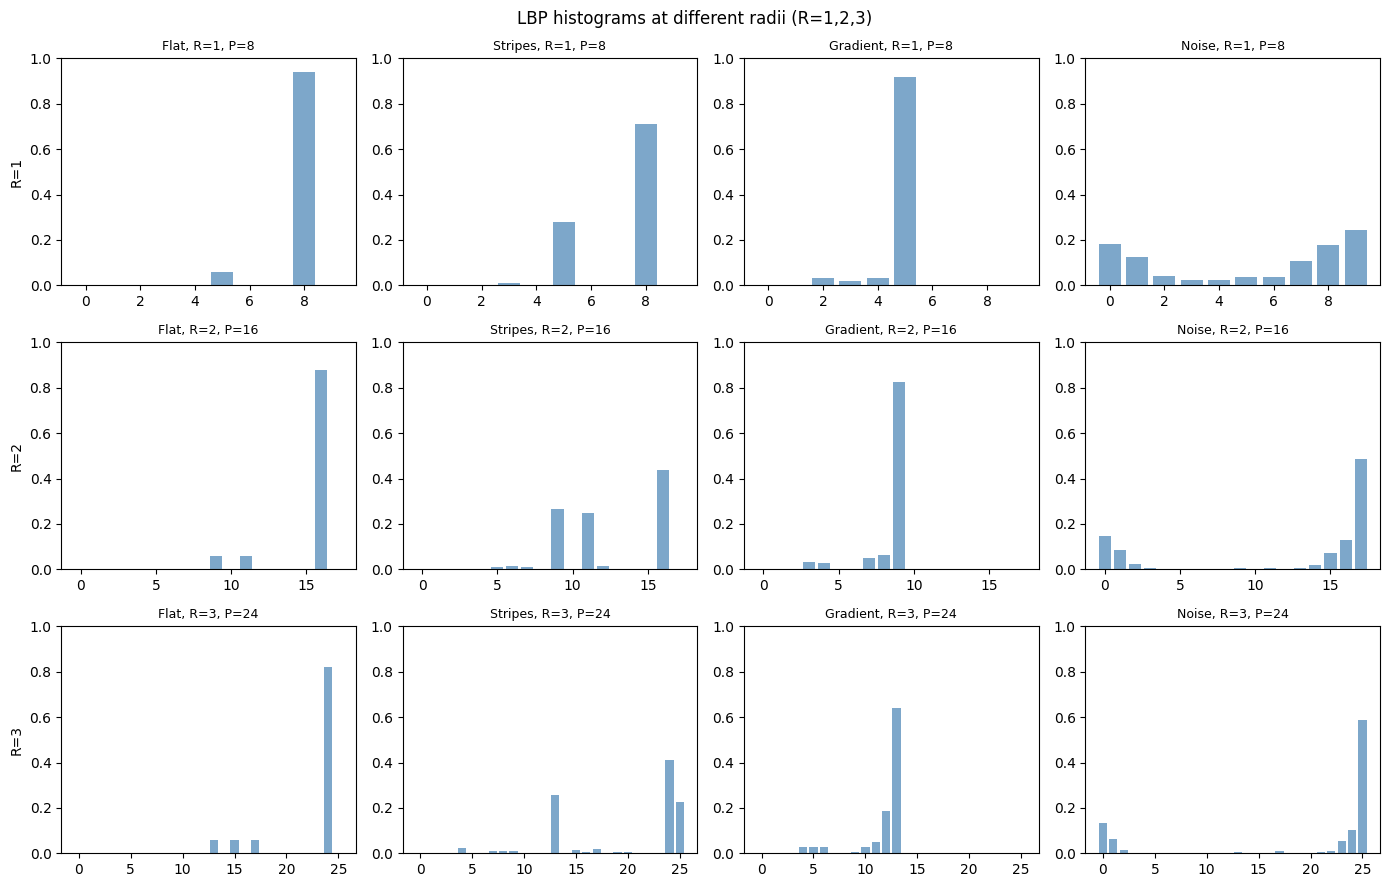

Larger radius captures coarser texture patterns.
In NB 22 we use all three (R=1,2,3) → 54 features total.


In [5]:
# Effect of radius: captures texture at different scales
fig, axes = plt.subplots(3, 4, figsize=(14, 9))
radii = [1, 2, 3]
n_points_list = [8, 16, 24]

# Use the stripes image to show scale sensitivity
test_img = img_stripes

for row, (r, p) in enumerate(zip(radii, n_points_list)):
    n_b = p + 2
    for col, (name, img) in enumerate(images.items()):
        lbp_img = local_binary_pattern(img, p, r, method="uniform")
        hist, _ = np.histogram(lbp_img, bins=n_b, range=(0, n_b), density=True)
        axes[row, col].bar(range(n_b), hist, color="steelblue", alpha=0.7)
        axes[row, col].set_title(f"{name}, R={r}, P={p}", fontsize=9)
        axes[row, col].set_ylim(0, 1.0)
        if col == 0:
            axes[row, col].set_ylabel(f"R={r}")

plt.suptitle("LBP histograms at different radii (R=1,2,3)", fontsize=12)
plt.tight_layout()
plt.show()

print("Larger radius captures coarser texture patterns.")
print("In NB 22 we use all three (R=1,2,3) → 54 features total.")

## Gabor Filters

### How it works

A Gabor filter is a **sinusoidal wave** modulated by a **Gaussian envelope**. It responds
to texture at a specific:
- **Frequency** (wavelength λ): how fine/coarse the pattern is
- **Orientation** (θ): what angle the pattern runs at

Think of it as asking: *"Is there a stripe pattern of width λ pixels at angle θ here?"*

The filter output (response) is high where the image matches that frequency/orientation,
and low elsewhere. We summarize each response map with mean and std to get features.

**Parameters in NB 22:**
- Wavelengths: 5, 10, 20 pixels (fine → coarse)
- Orientations: 0°, 30°, 60°, 90°, 120°, 150° (6 directions)
- σ = 0.56 × λ (Gaussian envelope width)
- γ = 0.5 (aspect ratio)
- Stats: mean, std, energy per response → 3 × 6 × 3 = 54 features

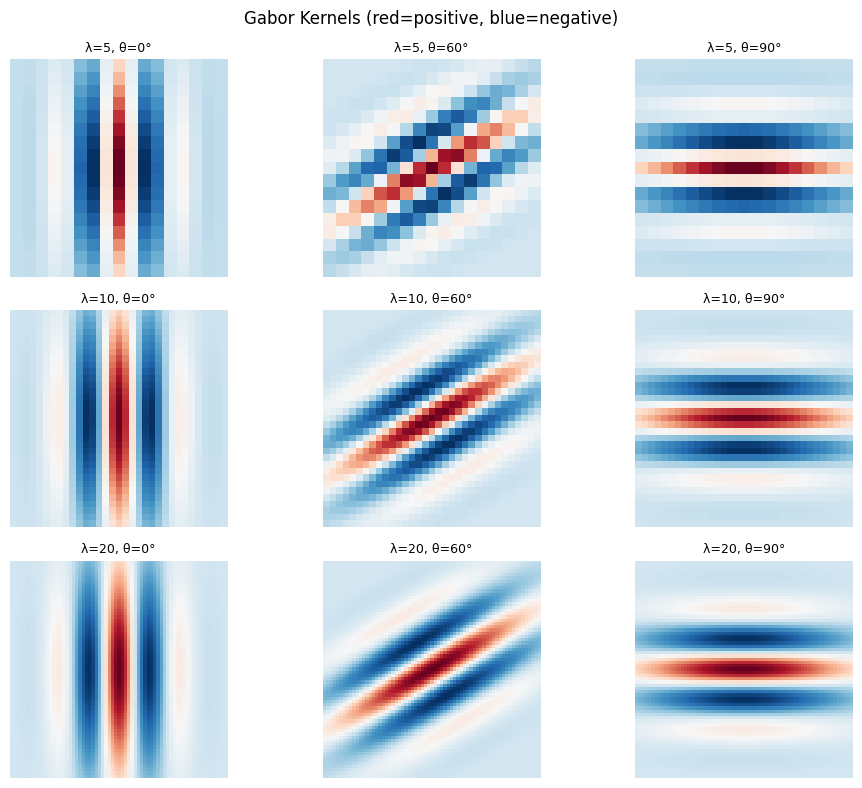

Each kernel is a localized sinusoid.
Small wavelength → fine detail. Large wavelength → coarse texture.
Orientation determines which direction of stripes it responds to.


In [6]:
# Visualize Gabor kernels: 2 wavelengths x 3 orientations
wavelengths = [5, 10, 20]
orientations = [0, 60, 90]

fig, axes = plt.subplots(len(wavelengths), len(orientations), figsize=(10, 8))

for i, wl in enumerate(wavelengths):
    for j, angle in enumerate(orientations):
        theta = np.deg2rad(angle)
        sigma = 0.56 * wl
        ksize = int(6 * sigma) | 1
        kernel = cv2.getGaborKernel(
            ksize=(ksize, ksize), sigma=sigma,
            theta=theta, lambd=wl, gamma=0.5, psi=0
        )
        axes[i, j].imshow(kernel, cmap="RdBu_r")
        axes[i, j].set_title(f"λ={wl}, θ={angle}°", fontsize=9)
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(f"λ={wl}px", fontsize=10)

plt.suptitle("Gabor Kernels (red=positive, blue=negative)", fontsize=12)
plt.tight_layout()
plt.show()

print("Each kernel is a localized sinusoid.")
print("Small wavelength → fine detail. Large wavelength → coarse texture.")
print("Orientation determines which direction of stripes it responds to.")

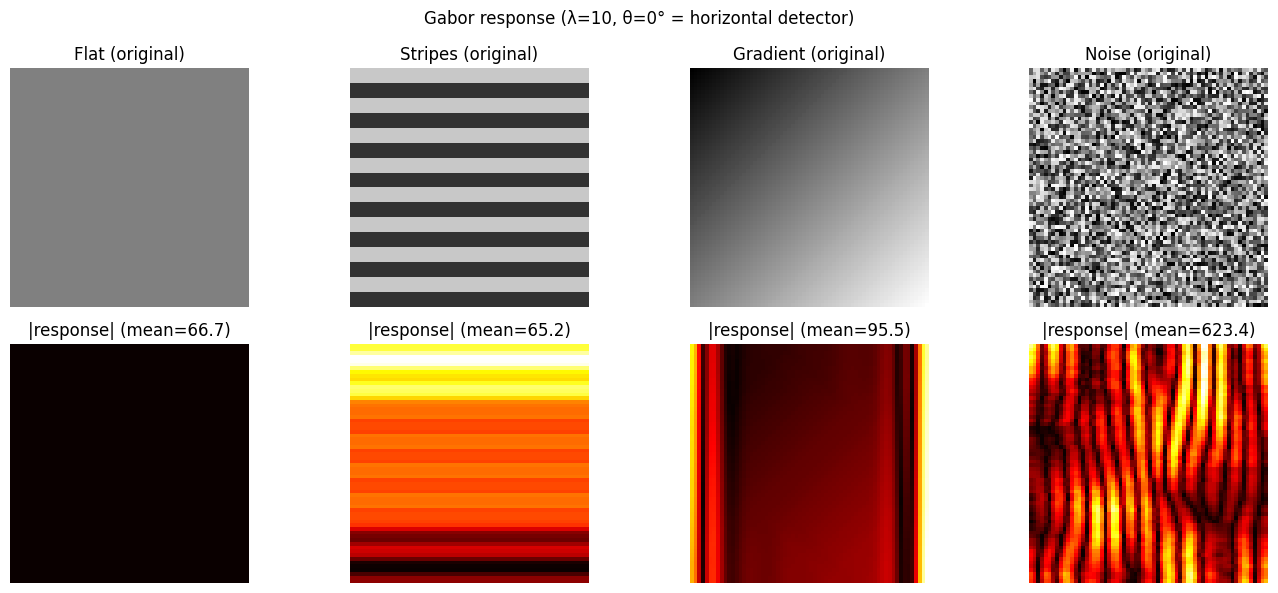

The horizontal stripes image gives the strongest response (matches the kernel).
Flat gives zero response (no texture to detect).
Noise gives moderate response everywhere (some accidental matches).


In [7]:
# Apply one Gabor kernel (lambda=10, theta=0) to all toy images
wl = 10
theta = 0  # horizontal stripes detector
sigma = 0.56 * wl
ksize = int(6 * sigma) | 1
kernel = cv2.getGaborKernel(
    ksize=(ksize, ksize), sigma=sigma,
    theta=np.deg2rad(theta), lambd=wl, gamma=0.5, psi=0
)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for col, (name, img) in enumerate(images.items()):
    response = cv2.filter2D(img.astype(np.float64), cv2.CV_64F, kernel)
    magnitude = np.abs(response)

    axes[0, col].imshow(img, cmap="gray", vmin=0, vmax=255)
    axes[0, col].set_title(f"{name} (original)")
    axes[0, col].axis("off")

    axes[1, col].imshow(magnitude, cmap="hot")
    axes[1, col].set_title(f"|response| (mean={magnitude.mean():.1f})")
    axes[1, col].axis("off")

plt.suptitle(f"Gabor response (λ={wl}, θ={theta}° = horizontal detector)", fontsize=12)
plt.tight_layout()
plt.show()

print("The horizontal stripes image gives the strongest response (matches the kernel).")
print("Flat gives zero response (no texture to detect).")
print("Noise gives moderate response everywhere (some accidental matches).")

In [8]:
# Multi-orientation extraction: how we get features from Gabor
wl = 10
all_orientations = [0, 30, 60, 90, 120, 150]

print(f"Wavelength = {wl}px, 6 orientations:")
print(f"{'Orientation':>12} {'Mean':>8} {'Std':>8} {'Energy':>10}")
print("-" * 42)

for angle in all_orientations:
    sigma = 0.56 * wl
    ksize = int(6 * sigma) | 1
    kernel = cv2.getGaborKernel(
        ksize=(ksize, ksize), sigma=sigma,
        theta=np.deg2rad(angle), lambd=wl, gamma=0.5, psi=0
    )
    response = cv2.filter2D(img_stripes.astype(np.float64), cv2.CV_64F, kernel)
    mag = np.abs(response)
    print(f"{angle:>12}°  {mag.mean():>8.2f} {mag.std():>8.2f} {np.mean(mag**2):>10.1f}")

print("\nThe 0° and 150°/30° orientations respond most to horizontal stripes.")
print("90° (vertical detector) gives weak response to horizontal texture.")
print("In total: 3 stats x 6 orientations x 3 wavelengths = 54 features.")

Wavelength = 10px, 6 orientations:
 Orientation     Mean      Std     Energy
------------------------------------------
           0°     65.17     2.83     4254.8
          30°     33.12    18.20     1428.5
          60°    127.63   150.02    38795.7
          90°   7948.32  3509.28 75490778.7
         120°    127.63   150.02    38795.7
         150°     33.12    18.20     1428.5

The 0° and 150°/30° orientations respond most to horizontal stripes.
90° (vertical detector) gives weak response to horizontal texture.
In total: 3 stats x 6 orientations x 3 wavelengths = 54 features.


## Laws' Texture Energy Measures

### How it works

Laws defined 5 simple 1D kernels that each detect a basic texture element:
- **L5** = [1, 4, 6, 4, 1] — **Level** (local averaging, like a smoothing filter)
- **E5** = [-1, -2, 0, 2, 1] — **Edge** (detects intensity transitions)
- **S5** = [-1, 0, 2, 0, -1] — **Spot** (detects isolated bright/dark points)
- **R5** = [1, -4, 6, -4, 1] — **Ripple** (detects rapid oscillations)
- **W5** = [-1, 2, 0, -2, 1] — **Wave** (detects wave-like patterns)

To make 2D kernels, take the **outer product** of two 1D kernels (one for rows, one for
columns). This gives 5×5 = 25 combinations, but since (A×B + B×A)/2 is symmetric,
we only need the 15 unique ones (upper triangle including diagonal).

Each 2D kernel is convolved with the image, and the response is summarized as:
mean(|response|), std(|response|), energy(mean of response²) → 3 stats × 15 kernels = 45 features.

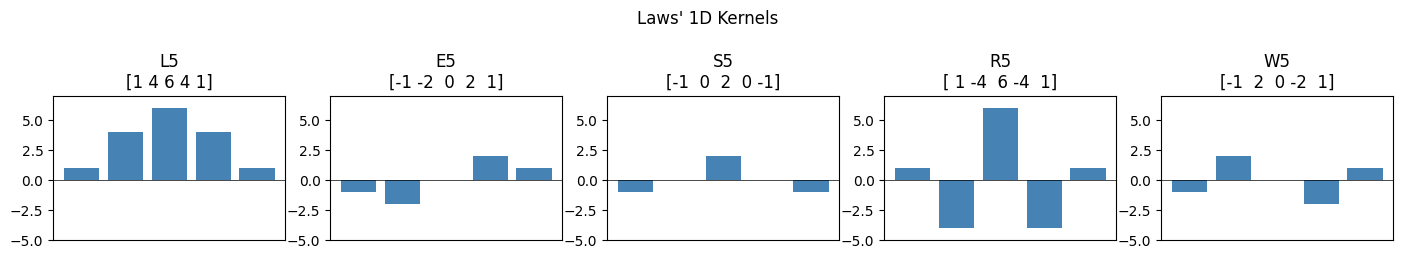

L5: smoothing (all positive weights centred)
E5: edge detection (antisymmetric, zero at centre)
S5: spot detection (negative-positive-negative)
R5: ripple detection (alternating signs)
W5: wave detection (similar to E5 but different phase)


In [9]:
# The 5 Laws' kernels
laws_kernels = {
    "L5": np.array([1, 4, 6, 4, 1], dtype=np.float64),
    "E5": np.array([-1, -2, 0, 2, 1], dtype=np.float64),
    "S5": np.array([-1, 0, 2, 0, -1], dtype=np.float64),
    "R5": np.array([1, -4, 6, -4, 1], dtype=np.float64),
    "W5": np.array([-1, 2, 0, -2, 1], dtype=np.float64),
}

fig, axes = plt.subplots(1, 5, figsize=(14, 2.5))
for ax, (name, kernel) in zip(axes, laws_kernels.items()):
    ax.bar(range(5), kernel, color="steelblue")
    ax.set_title(f"{name}\n{kernel.astype(int)}")
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xticks([])
    ax.set_ylim(-5, 7)

plt.suptitle("Laws' 1D Kernels", fontsize=12)
plt.tight_layout()
plt.show()

print("L5: smoothing (all positive weights centred)")
print("E5: edge detection (antisymmetric, zero at centre)")
print("S5: spot detection (negative-positive-negative)")
print("R5: ripple detection (alternating signs)")
print("W5: wave detection (similar to E5 but different phase)")

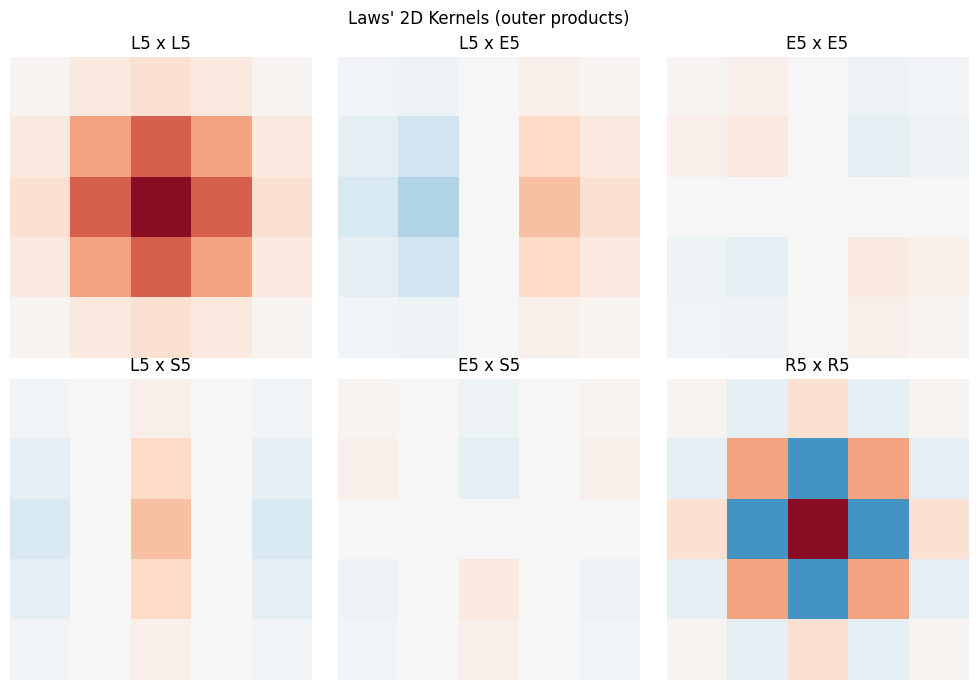


15 unique 2D kernel combinations (upper triangle):
  L5 x L5
  L5 x E5
  L5 x S5
  L5 x R5
  L5 x W5
  E5 x E5
  E5 x S5
  E5 x R5
  E5 x W5
  S5 x S5
  S5 x R5
  S5 x W5
  R5 x R5
  R5 x W5
  W5 x W5


In [10]:
# Show how 1D kernels combine into 2D via outer product
kernel_names = list(laws_kernels.keys())

# Show 6 example 2D kernels
examples = [("L5", "L5"), ("L5", "E5"), ("E5", "E5"), ("L5", "S5"), ("E5", "S5"), ("R5", "R5")]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for ax, (k1, k2) in zip(axes.flatten(), examples):
    kernel_2d = np.outer(laws_kernels[k1], laws_kernels[k2])
    ax.imshow(kernel_2d, cmap="RdBu_r", vmin=-40, vmax=40)
    ax.set_title(f"{k1} x {k2}")
    ax.axis("off")

plt.suptitle("Laws' 2D Kernels (outer products)", fontsize=12)
plt.tight_layout()
plt.show()

# Count unique combinations
unique_pairs = []
for i in range(5):
    for j in range(i, 5):
        unique_pairs.append((kernel_names[i], kernel_names[j]))
print(f"\n15 unique 2D kernel combinations (upper triangle):")
for pair in unique_pairs:
    print(f"  {pair[0]} x {pair[1]}")

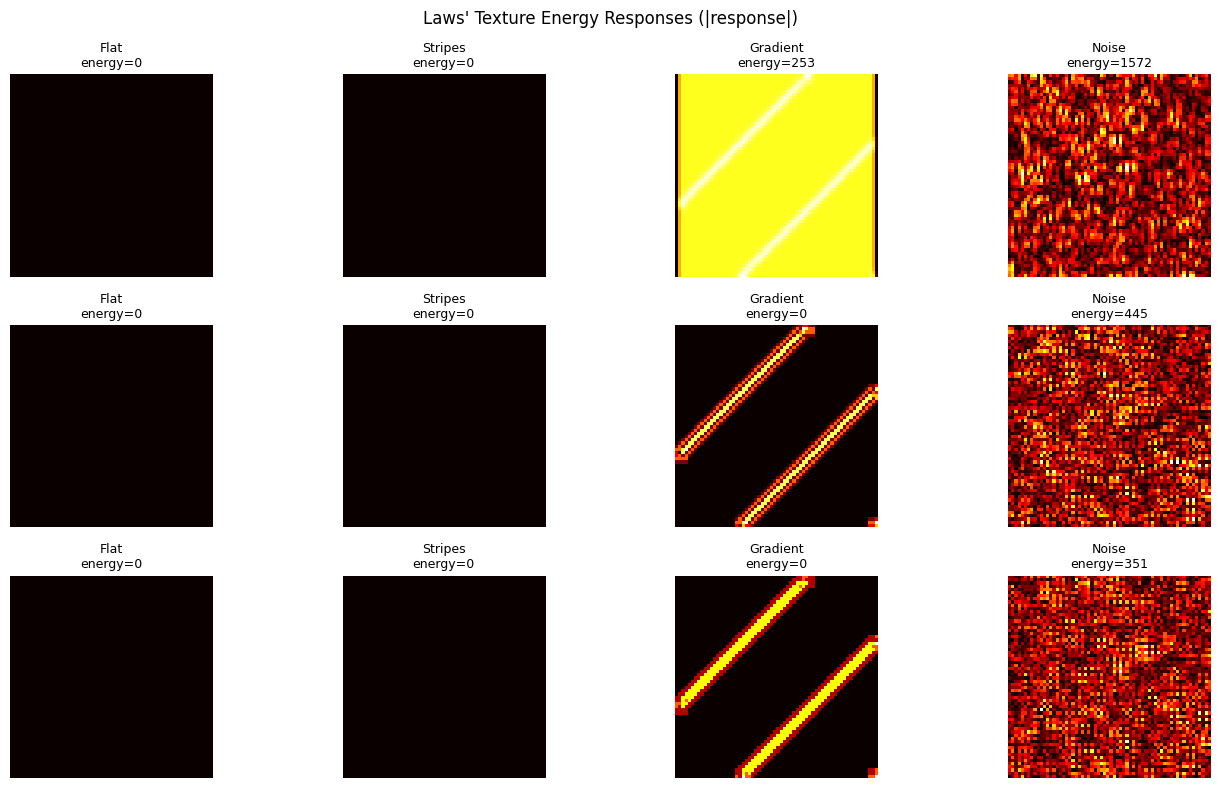

L5E5 (level x edge): responds to edges → strong on stripes
E5S5 (edge x spot): responds to complex texture → strong on noise
S5S5 (spot x spot): responds to isolated points → strongest on noise


In [11]:
# Apply Laws' kernels to toy images
# Show L5E5 (edge in one direction) and E5E5 (edges in both directions)
test_kernels = [("L5", "E5"), ("E5", "S5"), ("S5", "S5")]

fig, axes = plt.subplots(len(test_kernels), 4, figsize=(14, 8))

for row, (k1, k2) in enumerate(test_kernels):
    kernel_2d = np.outer(laws_kernels[k1], laws_kernels[k2])

    for col, (name, img) in enumerate(images.items()):
        response = convolve2d(img.astype(np.float64), kernel_2d, mode="same", boundary="symm")
        energy = np.mean(np.abs(response))

        axes[row, col].imshow(np.abs(response), cmap="hot")
        axes[row, col].set_title(f"{name}\nenergy={energy:.0f}", fontsize=9)
        axes[row, col].axis("off")

    axes[row, 0].set_ylabel(f"{k1}x{k2}", fontsize=10)

plt.suptitle("Laws' Texture Energy Responses (|response|)", fontsize=12)
plt.tight_layout()
plt.show()

print("L5E5 (level x edge): responds to edges → strong on stripes")
print("E5S5 (edge x spot): responds to complex texture → strong on noise")
print("S5S5 (spot x spot): responds to isolated points → strongest on noise")

## Comparison: what does each method capture?

Let's extract all three feature families from the stripes image and see how they
characterize the same texture differently.

In [12]:
# Feature extraction functions (simplified versions)
def get_lbp_features(img):
    feats = {}
    for radius, n_points in [(1, 8), (2, 16), (3, 24)]:
        lbp = local_binary_pattern(img, n_points, radius, method="uniform")
        hist, _ = np.histogram(lbp, bins=n_points+2, range=(0, n_points+2), density=True)
        feats[f"R{radius}_dominant_bin"] = np.argmax(hist)
        feats[f"R{radius}_uniformity"] = np.max(hist)  # how peaked is the histogram
    return feats

def get_gabor_features(img):
    feats = {}
    for wl in [5, 10, 20]:
        responses = []
        for angle in [0, 60, 90]:
            sigma = 0.56 * wl
            ksize = int(6 * sigma) | 1
            kernel = cv2.getGaborKernel(
                ksize=(ksize, ksize), sigma=sigma,
                theta=np.deg2rad(angle), lambd=wl, gamma=0.5, psi=0
            )
            resp = np.abs(cv2.filter2D(img.astype(np.float64), cv2.CV_64F, kernel))
            responses.append(resp.mean())
        feats[f"wl{wl}_best_orient"] = [0, 60, 90][np.argmax(responses)]
        feats[f"wl{wl}_max_response"] = max(responses)
    return feats

def get_laws_features(img):
    feats = {}
    for k1, k2 in [("L5", "E5"), ("E5", "E5"), ("S5", "S5")]:
        kernel_2d = np.outer(laws_kernels[k1], laws_kernels[k2])
        response = convolve2d(img.astype(np.float64), kernel_2d, mode="same", boundary="symm")
        feats[f"{k1}{k2}_energy"] = np.mean(np.abs(response))
    return feats

print("Feature comparison across toy images:")
print("=" * 70)
for name, img in images.items():
    print(f"\n{name}:")
    print(f"  LBP:   {get_lbp_features(img)}")
    print(f"  Gabor: {get_gabor_features(img)}")
    print(f"  Laws:  {get_laws_features(img)}")

Feature comparison across toy images:

Flat:
  LBP:   {'R1_dominant_bin': np.int64(8), 'R1_uniformity': np.float64(0.9384765625), 'R2_dominant_bin': np.int64(16), 'R2_uniformity': np.float64(0.87890625), 'R3_dominant_bin': np.int64(24), 'R3_uniformity': np.float64(0.8212890625)}
  Gabor: {'wl5_best_orient': 90, 'wl5_max_response': np.float64(11.553049829979273), 'wl10_best_orient': 0, 'wl10_max_response': np.float64(66.73099852556663), 'wl20_best_orient': 90, 'wl20_max_response': np.float64(237.7270699066191)}
  Laws:  {'L5E5_energy': np.float64(0.0), 'E5E5_energy': np.float64(0.0), 'S5S5_energy': np.float64(0.0)}

Stripes:
  LBP:   {'R1_dominant_bin': np.int64(8), 'R1_uniformity': np.float64(0.71142578125), 'R2_dominant_bin': np.int64(16), 'R2_uniformity': np.float64(0.439453125), 'R3_dominant_bin': np.int64(24), 'R3_uniformity': np.float64(0.41064453125)}
  Gabor: {'wl5_best_orient': 90, 'wl5_max_response': np.float64(1129.1210571802021), 'wl10_best_orient': 90, 'wl10_max_response': 

## Real ultrasound example

Apply all three methods to an actual pancreas ultrasound image from our dataset.

Image: (768, 1024), Mask pixels: 18299


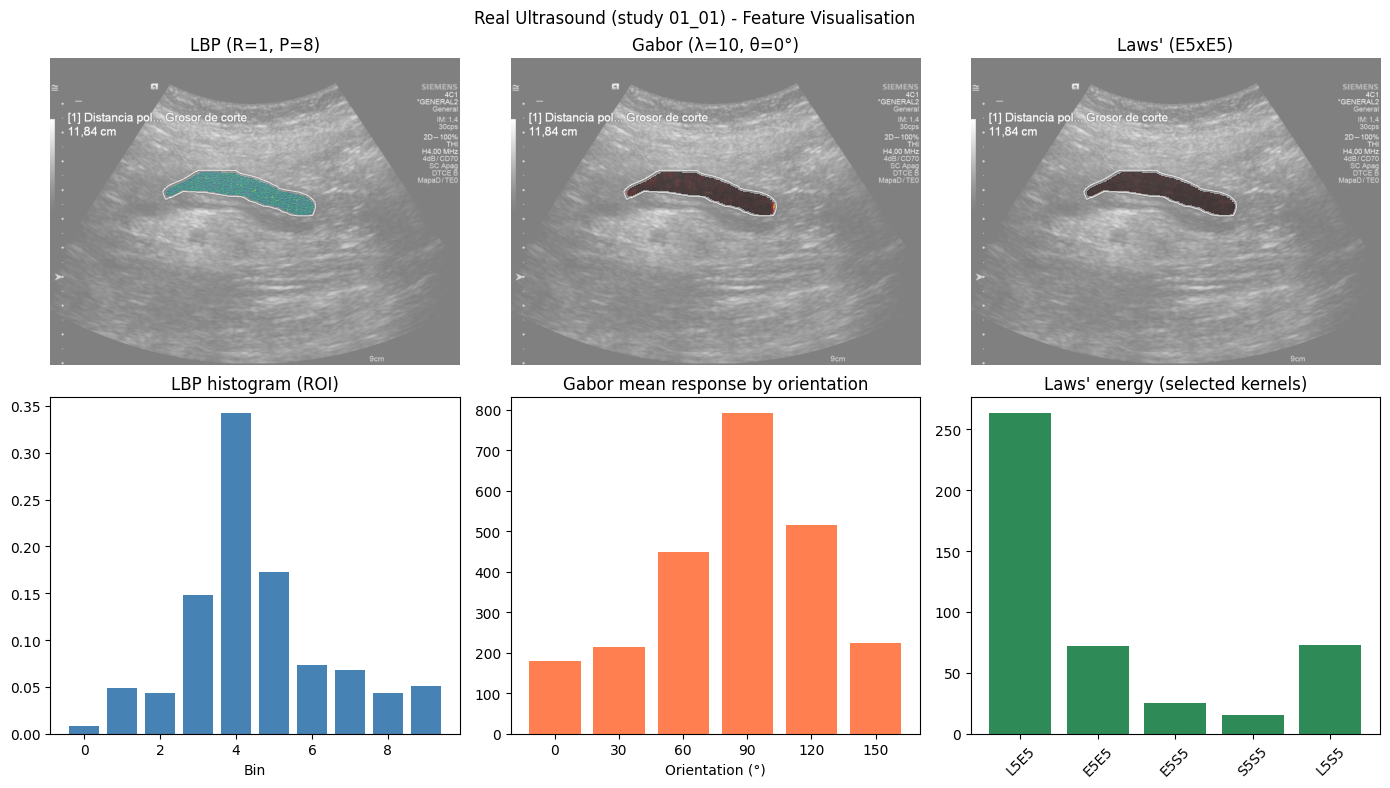

In [13]:
# Load one real image
raw_folder = os.path.join("..", "data", "PANCREAS_2", "PANCREAS_2")
mask_folder = os.path.join("..", "data", "PANCREAS_PREPROCESSED_CONTOUR_SUBTRACTED_ERODED_K3_I1", "masks")

study_id = "01_01"
patient_folder = os.path.join(raw_folder, study_id)
subfolders = [f for f in os.listdir(patient_folder) if not f.startswith(".")]
date_folder = os.path.join(patient_folder, subfolders[0])
files = [f for f in os.listdir(date_folder) if not f.startswith(".")]
ds = pydicom.dcmread(os.path.join(date_folder, files[0]))
pixels = ds.pixel_array
if len(pixels.shape) == 3:
    gray = cv2.cvtColor(pixels, cv2.COLOR_RGB2GRAY)
else:
    gray = pixels

mask_path = os.path.join(mask_folder, f"{study_id}_mask_eroded_k3_i1.png")
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask = (mask > 0).astype(np.uint8)
if gray.shape != mask.shape:
    mask = cv2.resize(mask, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_NEAREST)

print(f"Image: {gray.shape}, Mask pixels: {mask.sum()}")

# Show LBP, Gabor, Laws' on the real image
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# LBP map
lbp_real = local_binary_pattern(gray, 8, 1, method="uniform")
lbp_roi = lbp_real.copy()
lbp_roi[mask == 0] = np.nan
axes[0, 0].imshow(gray, cmap="gray", alpha=0.5)
axes[0, 0].imshow(lbp_roi, cmap="viridis", alpha=0.6)
axes[0, 0].set_title("LBP (R=1, P=8)")
axes[0, 0].axis("off")

# Gabor response (lambda=10, theta=0)
sigma = 0.56 * 10
ksize = int(6 * sigma) | 1
gk = cv2.getGaborKernel(ksize=(ksize, ksize), sigma=sigma, theta=0, lambd=10, gamma=0.5, psi=0)
gabor_resp = np.abs(cv2.filter2D(gray.astype(np.float64), cv2.CV_64F, gk))
gabor_roi = gabor_resp.copy()
gabor_roi[mask == 0] = np.nan
axes[0, 1].imshow(gray, cmap="gray", alpha=0.5)
axes[0, 1].imshow(gabor_roi, cmap="hot", alpha=0.6)
axes[0, 1].set_title("Gabor (λ=10, θ=0°)")
axes[0, 1].axis("off")

# Laws' E5E5 response
laws_kernel = np.outer(laws_kernels["E5"], laws_kernels["E5"])
laws_resp = np.abs(convolve2d(gray.astype(np.float64), laws_kernel, mode="same", boundary="symm"))
laws_roi = laws_resp.copy()
laws_roi[mask == 0] = np.nan
axes[0, 2].imshow(gray, cmap="gray", alpha=0.5)
axes[0, 2].imshow(laws_roi, cmap="hot", alpha=0.6)
axes[0, 2].set_title("Laws' (E5xE5)")
axes[0, 2].axis("off")

# Bottom row: histograms/summaries
lbp_masked = lbp_real[mask > 0]
hist_lbp, _ = np.histogram(lbp_masked, bins=10, range=(0, 10), density=True)
axes[1, 0].bar(range(10), hist_lbp, color="steelblue")
axes[1, 0].set_title("LBP histogram (ROI)")
axes[1, 0].set_xlabel("Bin")

# Gabor responses across orientations
orientations = [0, 30, 60, 90, 120, 150]
gabor_means = []
for angle in orientations:
    sigma = 0.56 * 10
    ksize = int(6 * sigma) | 1
    gk = cv2.getGaborKernel(ksize=(ksize, ksize), sigma=sigma, theta=np.deg2rad(angle), lambd=10, gamma=0.5, psi=0)
    resp = np.abs(cv2.filter2D(gray.astype(np.float64), cv2.CV_64F, gk))
    gabor_means.append(resp[mask > 0].mean())
axes[1, 1].bar([str(o) for o in orientations], gabor_means, color="coral")
axes[1, 1].set_title("Gabor mean response by orientation")
axes[1, 1].set_xlabel("Orientation (°)")

# Laws' energies
laws_pairs_show = [("L5","E5"), ("E5","E5"), ("E5","S5"), ("S5","S5"), ("L5","S5")]
laws_energies = []
for k1, k2 in laws_pairs_show:
    k2d = np.outer(laws_kernels[k1], laws_kernels[k2])
    resp = convolve2d(gray.astype(np.float64), k2d, mode="same", boundary="symm")
    laws_energies.append(np.mean(np.abs(resp[mask > 0])))
axes[1, 2].bar([f"{a}{b}" for a, b in laws_pairs_show], laws_energies, color="seagreen")
axes[1, 2].set_title("Laws' energy (selected kernels)")
axes[1, 2].tick_params(axis="x", rotation=45)

plt.suptitle(f"Real Ultrasound (study {study_id}) - Feature Visualisation", fontsize=12)
plt.tight_layout()
plt.show()

## Summary

| Method | What it captures | Scale control | Features in NB 22 |
|--------|-----------------|--------------|-------------------|
| LBP | Local micro-patterns (edges, corners, flat regions) | Radius (1, 2, 3) | 54 |
| Gabor | Periodic texture at specific frequency/orientation | Wavelength (5, 10, 20) | 54 |
| Laws' | Texture energy from predefined micro-structure detectors | Fixed kernel size (5x5) | 45 |

**Key takeaways:**
- These three methods are **complementary**: LBP captures local comparisons, Gabor
  captures periodic/oriented texture, Laws' captures specific micro-structures.
- They are fundamentally different from PyRadiomics features (which use GLCM, GLRLM,
  etc. based on gray-level co-occurrences and run lengths).
- In our dataset, **none of the 153 features discriminated rejection** from non-rejection
  (0/153 FDR-significant, all ML models AUC ≈ 0.5). This confirms that the negative
  finding is not an artifact of the specific feature extraction method — it reflects a
  fundamental limitation of B-mode ultrasound texture for this task.